In [20]:
from polargrid import polargrid

In [21]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import math

def init(n):
    d = 2
    points = np.random.randn(n, d)
    radius = np.random.uniform(0, 1, size=n)**(1/d)
    points = points / np.linalg.norm(points, axis=1, keepdims=True) * radius[:, None]
    plt.plot(points[:,0], points[:, 1])
    plt.title("initial distribution (in the euclidian space)")
    plt.show()
    grid = polargrid(points)
    return grid

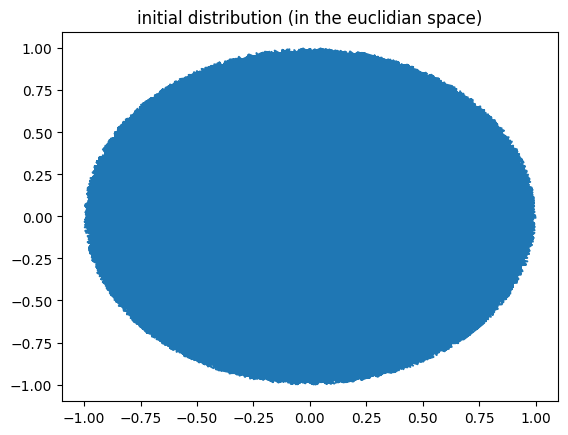

In [22]:
grid = init(200*200)

In [23]:
import seaborn

def dist(x, y):
    return np.linalg.norm(grid - grid[x, y], axis=-1)

def gdist(x, y, sigma):
    d = dist(x, y)
    return np.exp( -(d**2)/sigma**2)

n = grid.shape[0]

In [24]:
x, y = np.random.choice(n), np.random.choice(n)
print(x, y)

94 62


If everything went ok, the mapping preserved distance and thus following plot shall display a nice red spot

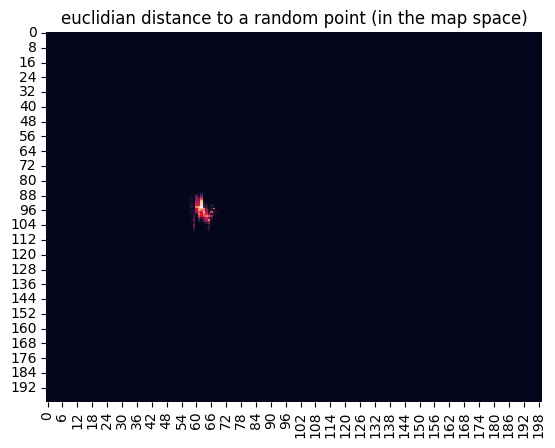

In [25]:
gd = gdist(x, y, sigma = 0.03)
seaborn.heatmap(gd, cbar=False)
plt.title("euclidian distance to a random point (in the map space)")
plt.show()